In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\ADEEKSHA\Downloads\insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [4]:
df.shape

(27, 2)

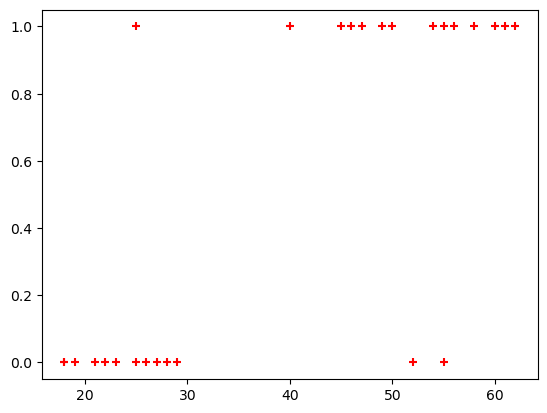

In [5]:
plt.scatter(df.age,df.bought_insurance,color='red',marker="+")

In [7]:
x=df[['age']]
y=df[['bought_insurance']]

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.8,random_state=42)

In [11]:
x_test

,age
8,62
13,29
9,61
21,26
0,22
11,28
16,25
17,58
12,27
24,50


In [13]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\ADEEKSHA\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [14]:
model.coef_

array([[0.11523991]])

In [16]:
model.intercept_

array([-5.64857389])

In [17]:
y_predicted=model.predict(x_test)

In [18]:
y_predicted

array([1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0],
      dtype=int64)

In [25]:
df['probs']=model.predict_proba(df[['age']])[:,1]

In [26]:
df

,age,bought_insurance,probs
0,22,0,0.042562
1,25,0,0.059102
2,47,1,0.442185
3,52,0,0.585138
4,46,1,0.413980
5,56,1,0.691013
6,55,0,0.665883
7,60,1,0.780026
8,62,1,0.817022
9,61,1,0.799161


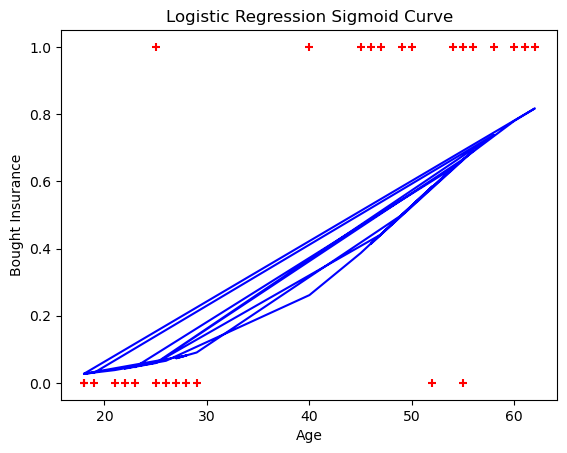

In [28]:
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
plt.plot(df['age'], df['probs'], color='blue')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.title("Logistic Regression Sigmoid Curve")
plt.show()

In [31]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

In [34]:
def prediction_function(age):
    z=0.112*age+(-4.20)
    y=sigmoid(z)
    return y

In [35]:
age=35
prediction_function(age)

0.43045377606077095

In [36]:
age=40
prediction_function(age)

0.569546223939229

In [37]:
age=37
prediction_function(age)

0.4860036575196728

In [38]:
age=37.5
prediction_function(age)

0.5

In [39]:
#82,66,58,77,13,1

In [40]:
age=82
prediction_function(age)

0.9931999362344026

In [41]:
age=66
prediction_function(age)

0.9605321106735979

In [42]:
age=58
prediction_function(age)

0.9085452184644403

In [43]:
age=77
prediction_function(age)

0.9881557756401541

In [44]:
age=13
prediction_function(age)

0.0604264033944818

In [45]:
age=1
prediction_function(age)

0.016496061288316648

In [46]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x)
accuracy=accuracy_score(y,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.7037037037037037
